## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# import libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
# to compute classification model
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

# to define a common seed value to be used throughout
RS=42

# to suppress unnecessary warning
import warnings
warnings.filterwarnings('ignore')

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

## Loading the dataset

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load dataset into a pandas dataframe
alllife_bank_customers_details = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Loan_Modelling.csv")

In [ ]:
# creating a copy of the data
data = alllife_bank_customers_details.copy()

## Data Overview

* Observations
* Sanity checks

### Viewing the first and last 5 rows of the dataset

In [ ]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Checking the shape of the dataset.

In [ ]:
data.shape

(5000, 14)

- The dataset has 5000 rows and 14 columns.

### Checking the attribute types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- There are 14 numerical and 0 categorical variables in the data.

### Checking the statistical summary

In [ ]:
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


- On average, customers have an annual household income of ~$74k
- The standard deviation for Income is about 46,033, which is quite large, indicating a wide range of incomes.
- The age of the customers ranges from 23 to 67 years

### Checking for missing values

In [ ]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


- There are no missing values in the data.

### Checking for duplicate values

In [ ]:
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

### 1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

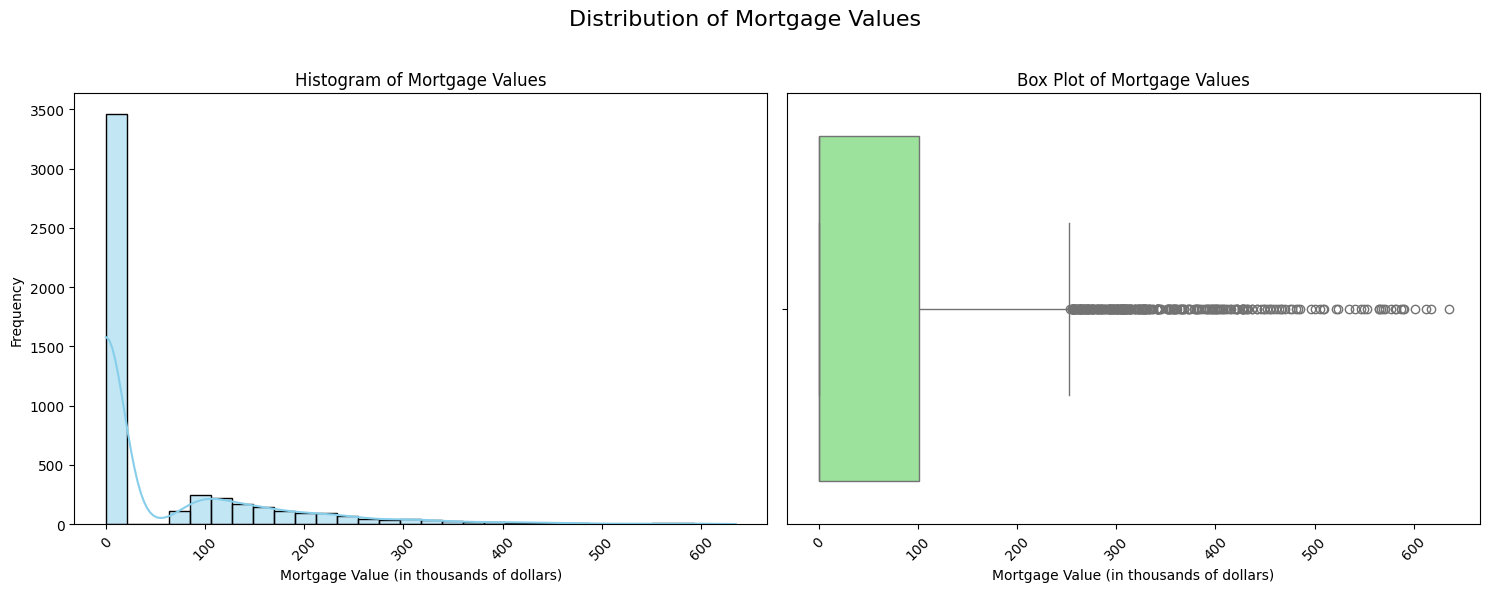

In [ ]:
# distribution of mortgage attribute
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribution of Mortgage Values', fontsize=16)

sns.histplot(data['Mortgage'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Mortgage Values', fontsize=12)
axes[0].set_xlabel('Mortgage Value (in thousands of dollars)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Boxplot for non-zero mortgage values
sns.boxplot(x=data['Mortgage'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot of Mortgage Values', fontsize=12)
axes[1].set_xlabel('Mortgage Value (in thousands of dollars)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])

- The distribution of the Mortgage attribute is highly skewed. A significant majority of the customers, 3462 out of 5000 (69.24%), have a mortgage value of $0. This indicates that most customers either do not have a mortgage with the bank or have a fully paid-off mortgage

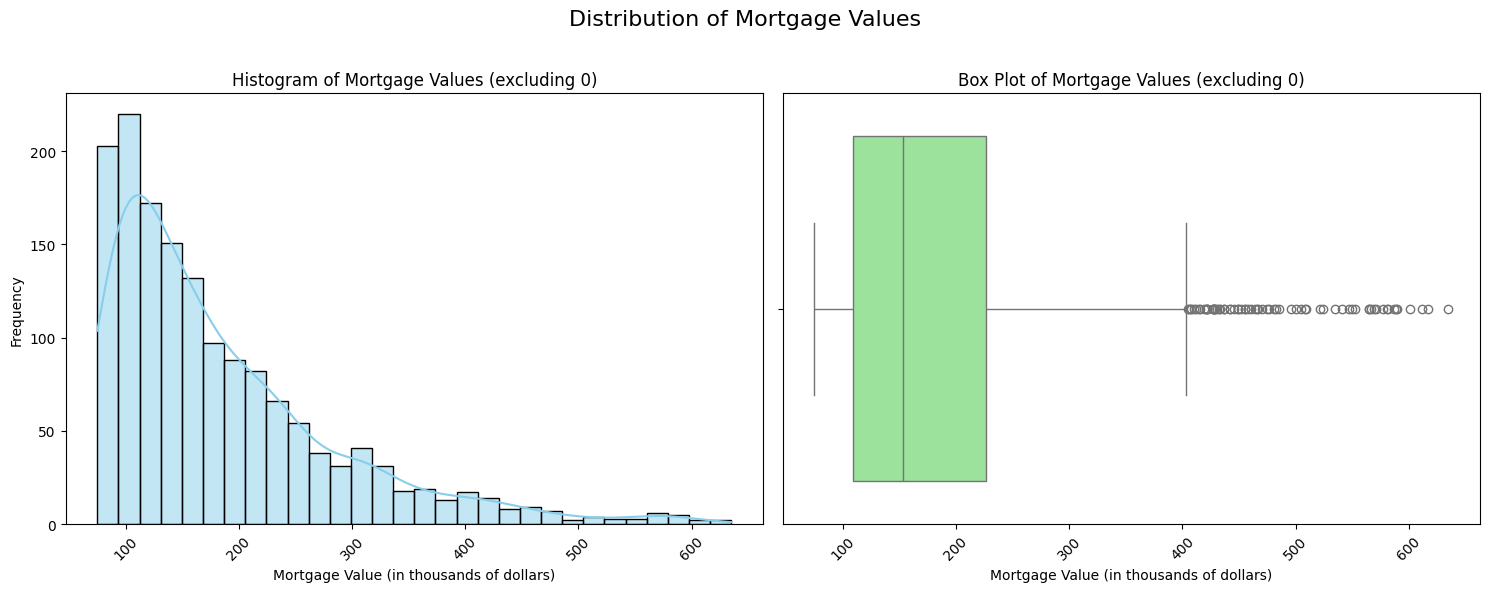

In [ ]:
# Filter out zero values for better visualization of non-zero mortgage values
non_zero_mortgage = data[data['Mortgage'] > 0]['Mortgage']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribution of Mortgage Values', fontsize=16)

# Histogram for non-zero mortgage values
sns.histplot(non_zero_mortgage, bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Mortgage Values (excluding 0)', fontsize=12)
axes[0].set_xlabel('Mortgage Value (in thousands of dollars)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Boxplot for non-zero mortgage values
sns.boxplot(x=non_zero_mortgage, ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot of Mortgage Values (excluding 0)', fontsize=12)
axes[1].set_xlabel('Mortgage Value (in thousands of dollars)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])

- For the customers with a mortgage value greater than 0, the distribution is heavily concentrated at the lower end, with a long tail extending to higher values. The box plot confirms that there are many outliers in the mortgage amounts, suggesting a few customers hold very high mortgage balances.

### Question 2: How many customers have credit cards?

In [ ]:
num_customers_with_credit_cards = data['CreditCard'].sum()
print(f"\nNumber of customers with a credit card: {num_customers_with_credit_cards}")
print(f"Percentage of customers with a credit card: {num_customers_with_credit_cards / len(data) * 100:.2f}%")


Number of customers with a credit card: 1470
Percentage of customers with a credit card: 29.40%


- Dataset has 1470 customers who have a credit card issued by any other Bank (excluding All life Bank), accounts for 29.40% of the total customer base.

### 3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

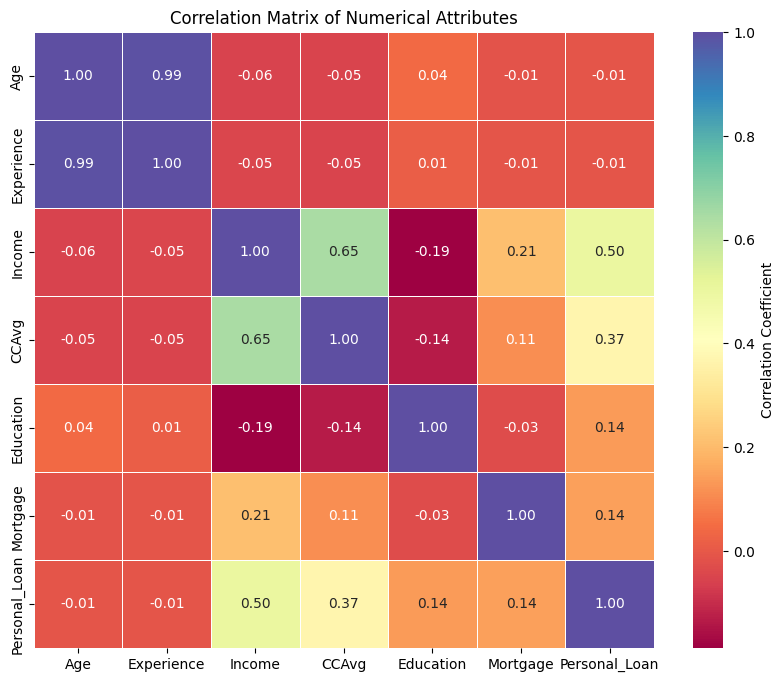

In [ ]:
# selecting numerical columns
numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan']

# calculate correlation matrix
corr_matrix = data[numerical_cols].corr()

# correlation with 'personal_load'
corr_with_personal_loan = corr_matrix['Personal_Loan'].sort_values(ascending=False)

# heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Spectral', fmt='.2f',
            linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numerical Attributes')
plt.show()


- Income has the strongest positive correlation with Personal_Loan, with a correlation coefficient of 0.50
- CCAvg (Average Credit Card Spending) also has a strong positive correlation of 0.37, suggesting that customers with higher credit card spending are more prone to taking a loan

### 4. How does a customer's interest in purchasing a loan vary with their age?

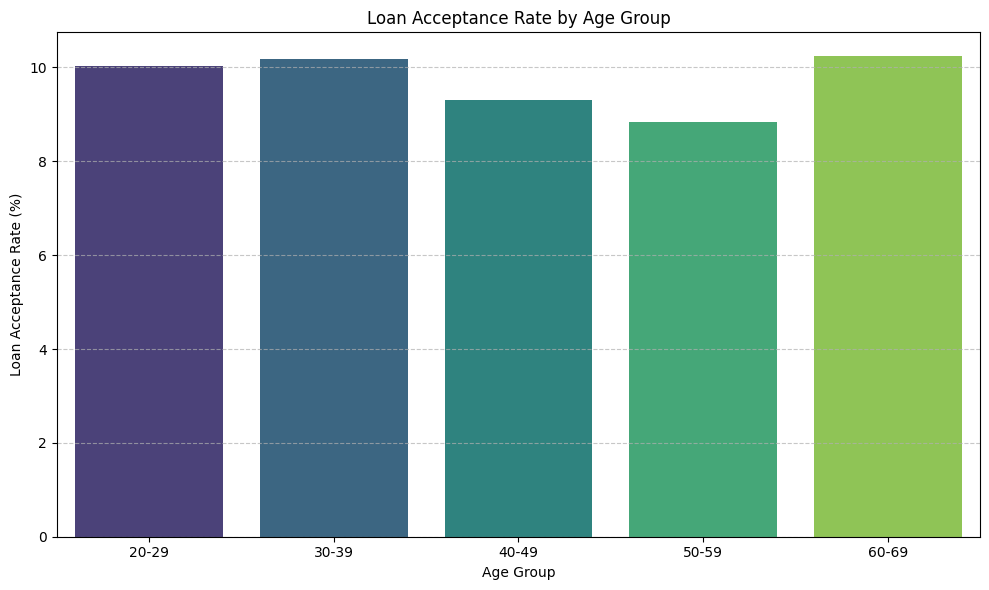

In [ ]:
# define age bins and labels
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69']

# create a new collumn age_group
data['age_group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

# calculate the loan acceptance rate per age group
loan_acceptance_by_age = data.groupby('age_group')['Personal_Loan'].mean().reset_index()
loan_acceptance_by_age['Personal_Loan'] = loan_acceptance_by_age['Personal_Loan'] * 100
loan_acceptance_by_age.rename(columns={'Personal_Loan': 'Loan Acceptance Rate (%)'}, inplace=True)

# defining the figure size
plt.figure(figsize=(10, 6))
sns.barplot(data=loan_acceptance_by_age, x='age_group', y='Loan Acceptance Rate (%)', palette='viridis')
plt.title('Loan Acceptance Rate by Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Age Group')

plt.tight_layout()
plt.show();

- No strong patterns or significant variations were found
- The acceptance rates for a personal loan are relatively consistent   across all age groups, fluctuating between 8.8% and 10.2%.
- This suggests that age, on its own, is not a strong predictor of a customer's interest in a personal loan.

### 5.How does a customer's interest in purchasing a loan vary with their education?

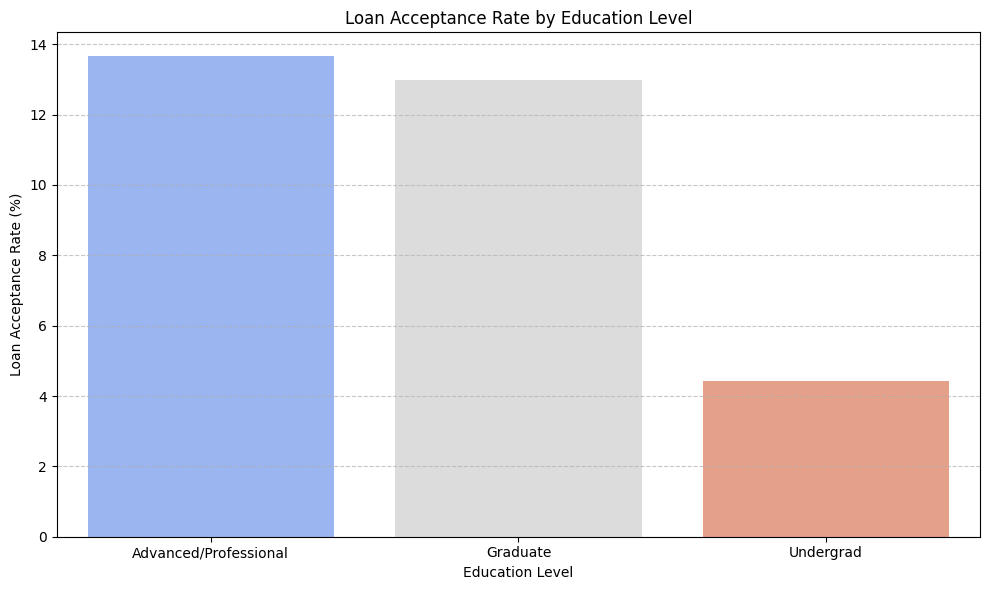

In [ ]:
# define map for education levels
education_map = {1: 'Undergrad', 2: 'Graduate', 3: 'Advanced/Professional'}

# map the education levels
data['Education_Level'] = data['Education'].map(education_map)

# calculate the loan acceptance rate per education level
loan_acceptance_by_education = data.groupby('Education_Level')['Personal_Loan'].mean().reset_index()
loan_acceptance_by_education['Personal_Loan'] = loan_acceptance_by_education['Personal_Loan'] * 100
loan_acceptance_by_education.rename(columns={'Personal_Loan': 'Loan Acceptance Rate (%)'}, inplace=True)

# defining the figure size
plt.figure(figsize=(10, 6))
sns.barplot(data=loan_acceptance_by_education, x='Education_Level', y='Loan Acceptance Rate (%)', palette='coolwarm')
plt.title('Loan Acceptance Rate by Education Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Education Level')

plt.tight_layout()
plt.show();

- The analysis reveals a clear relationship between a customer's education and their interest in a personal loan.
- Customers with a Graduate or Advanced/Professional degree are significantly more likely to accept a personal loan compared to those with an Undergraduate degree.
- This suggests that education level is a key factor in predicting a customer's interest in a personal loan.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

### Missing value treatment

In [ ]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


- No missing values

### Feature engineering (if needed)

In [ ]:
# Drop ID, ZIP Code, Education_Level and age_group columns
data.drop(columns=['ID', 'ZIPCode', 'Education_Level', 'age_group'], inplace=True)
# convert education column to a one-hot encoded format
data = pd.get_dummies(data, columns=['Education'], prefix=['Education'], dtype=int)
data.head()

,Age,Experience,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Education_1,Education_2,Education_3
0,25,1,49,4,1.6,0,0,1,0,0,0,1,0,0
1,45,19,34,3,1.5,0,0,1,0,0,0,1,0,0
2,39,15,11,1,1.0,0,0,0,0,0,0,1,0,0
3,35,9,100,1,2.7,0,0,0,0,0,0,0,1,0
4,35,8,45,4,1.0,0,0,0,0,0,1,0,1,0


In [ ]:
# check negative values in experience
negative_exp_count = (data['Experience'] < 0).sum()
print(f"Number of negative values in 'Experience': {negative_exp_count}")

Number of negative values in 'Experience': 52


In [ ]:
# Check the relationship between Age and Experience
if negative_exp_count > 0:
  data['calculated_experience'] = data['Age'] - 24 # Assuming people start work at 24
  # Impute negative 'Experience' values with calculated experience
  data.loc[data['Experience'] < 0, 'Experience'] = data.loc[data['Experience'] < 0, 'calculated_experience']

  # ensure imputed experience is not negative
  data['Experience'] = data['Experience'].clip(lower=0)

  # drop temp column
  data.drop(columns=['calculated_experience'], inplace=True)

negative_exp_count = (data['Experience'] < 0).sum()
print(f"Number of negative values in 'Experience': {negative_exp_count}")



Number of negative values in 'Experience': 0


### Outlier detection and treatment

In [ ]:
# outliers in 'Mortgage' and 'CCAvg'
numerical_features = ['Mortgage', 'CCAvg']

# Detect & cap outliers - use IQR method
def cap_outliers(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
  return data

# Apply outlier capping to numerical features
for feature in numerical_features:
  data = cap_outliers(data, feature)

print(f"Outliers in {numerical_features} have been capped")

Outliers in ['Mortgage', 'CCAvg'] have been capped


### Preparing data for modeling

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()
columns_to_scale = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']

# Replace the original columns with the scaled versions
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

data.head()

,Age,Experience,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Education_1,Education_2,Education_3
0,-1.774417,-1.673936,-0.538229,1.397414,-0.159316,-0.608391,0,1,0,0,0,1,0,0
1,-0.029524,-0.098665,-0.864109,0.525991,-0.228183,-0.608391,0,1,0,0,0,1,0,0
2,-0.552992,-0.448725,-1.363793,-1.216855,-0.572519,-0.608391,0,0,0,0,0,1,0,0
3,-0.901970,-0.973816,0.569765,-1.216855,0.598223,-0.608391,0,0,0,0,0,0,1,0
4,-0.901970,-1.061331,-0.625130,1.397414,-0.572519,-0.608391,0,0,0,0,1,0,1,0


## Model Building

### Model Evaluation Criterion

In [ ]:
# Define features (X) and target (y)
X = data.drop('Personal_Loan', axis=1)
y = data['Personal_Loan']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RS, stratify=y)


In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def evaluate_model(model, predictors, target):

  # predicting using the independent variables
  pred = model.predict(predictors)

  acc = accuracy_score(target, pred)    # to compute Accuracy
  recall = recall_score(target, pred)   # to compute Recall
  pre = precision_score(target, pred)   # to compute Precision
  f1 = f1_score(target, pred)

  # creating dataframe of metrics
  df_perf = pd.DataFrame(
      {'Accuracy': acc, 'Recall': recall, 'Precision': pre, 'F1 Score': f1,},
      index=[0],
    )

  return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):

  # predicting using the independent variables
  y_pred = model.predict(predictors)

  # confusion matrix
  cm = confusion_matrix(target, y_pred)

  # Create labels for each cell in the confusion matrix with both count and percentage
  labels = np.asarray(
      [
          ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
          for item in cm.flatten()
      ]
  ).reshape(2, 2)    # reshaping to a matrix

  # plot confusion matrix
  plt.figure(figsize=(12 ,5))
  plt.suptitle("Confusion Matrix", fontsize=16)

  sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  plt.show()


### Model Building

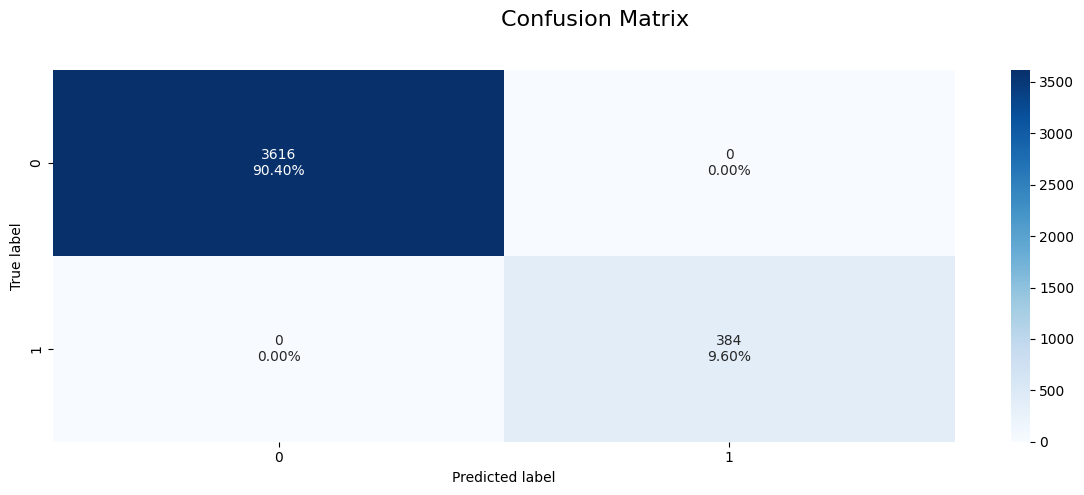

In [ ]:
# creating an instance of the decision tree model
dtree1 = DecisionTreeClassifier(random_state=42)

# fitting the model on the training data
dtree1.fit(X_train, y_train)

# plot confusion matrix
plot_confusion_matrix(dtree1, X_train, y_train)

In [ ]:
dtree1_train_perf = evaluate_model(
    dtree1, X_train, y_train
  )
dtree1_train_perf

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


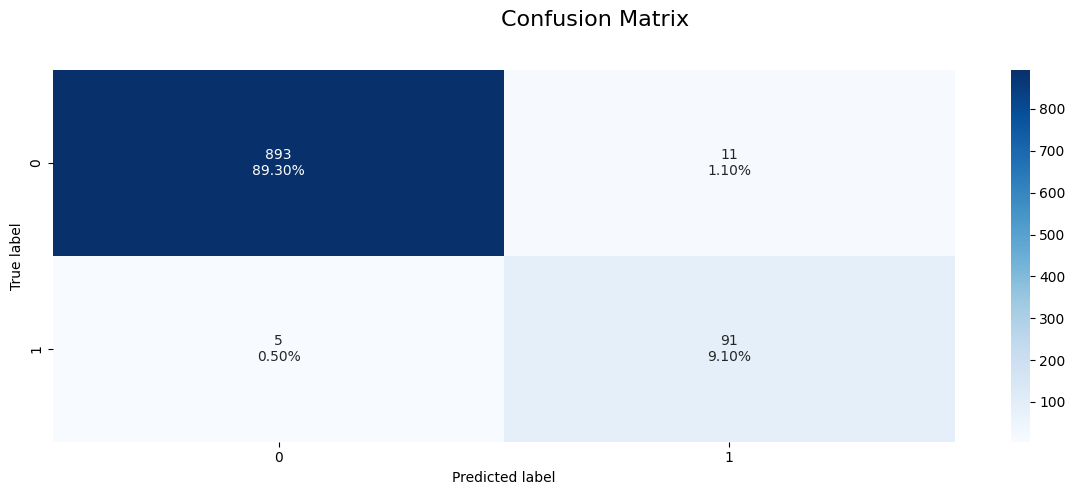

In [ ]:
plot_confusion_matrix(dtree1, X_test, y_test)

In [ ]:
dtree1_test_perf = evaluate_model(
    dtree1, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.984,0.947917,0.892157,0.919192


- The difference between the training and test F1 Score indicates that the model is overfitting.


#### Visualizing the Decision Tree

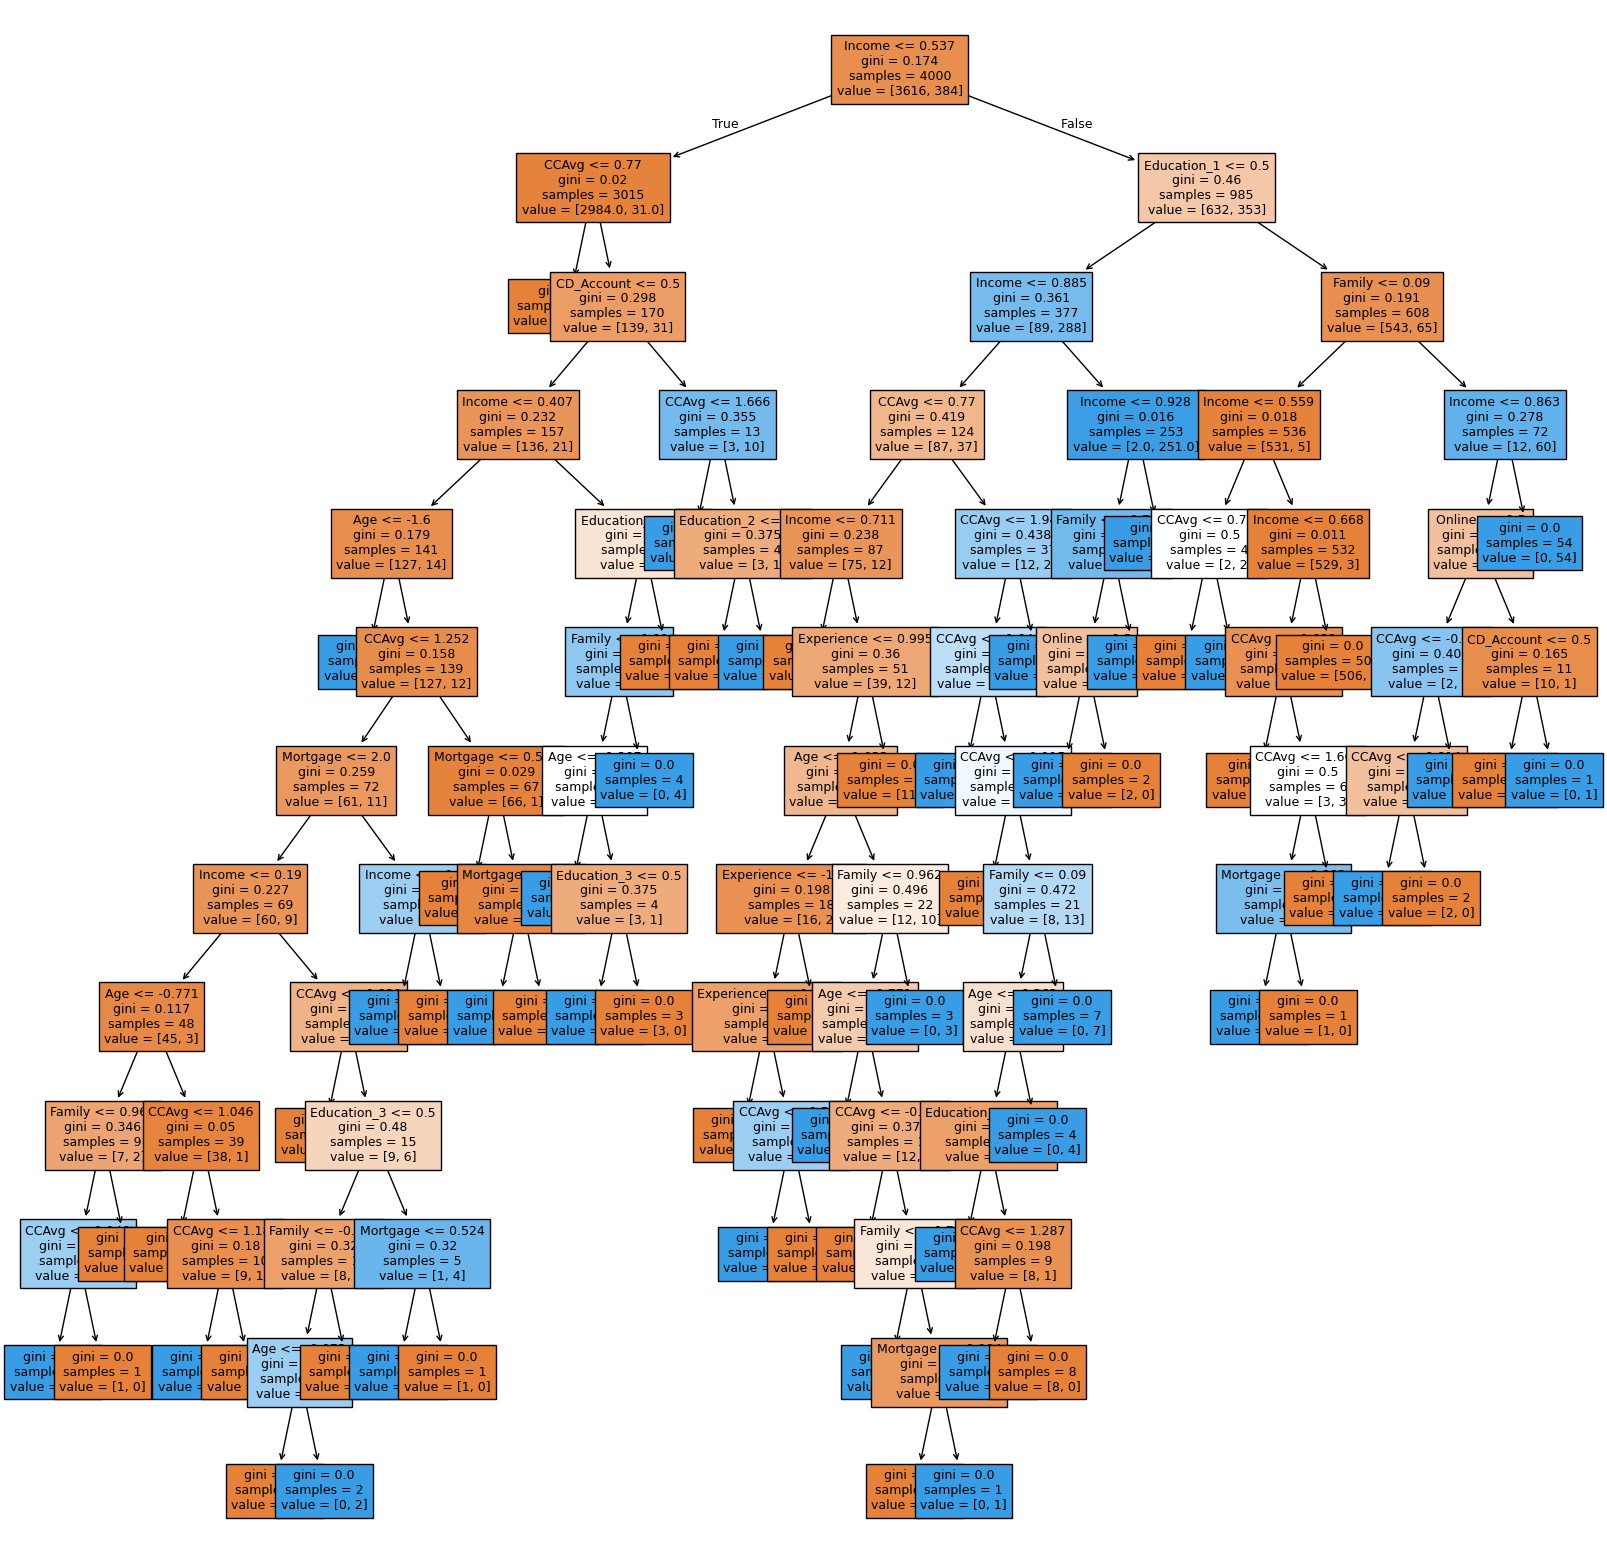

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                           # decision tree classifier model
    feature_names = feature_names,    # list of feature names (columns) in the dataset
    filled=True,                      # fill the nodes with colors based on class
    fontsize=9,                       # font size of the text in the plot
    node_ids=False,                    # do not show the ID of each node
    class_names=None,                 # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
  arrow = o.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor('black')      # set arrow color to black
    arrow.set_linewidth(1)            # set arrow width to 1

# displaying the plot
plt.show()

- This is a very complex tree.

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree1,                           # specify the model
        feature_names = feature_names,    # specify the feature names
        show_weights=True                 # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 0.54
|   |--- CCAvg <= 0.77
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  0.77
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 0.41
|   |   |   |   |--- Age <= -1.60
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  -1.60
|   |   |   |   |   |--- CCAvg <= 1.25
|   |   |   |   |   |   |--- Mortgage <= 2.00
|   |   |   |   |   |   |   |--- Income <= 0.19
|   |   |   |   |   |   |   |   |--- Age <= -0.77
|   |   |   |   |   |   |   |   |   |--- Family <= 0.96
|   |   |   |   |   |   |   |   |   |   |--- CCAvg <= 1.15
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |   |   |   |--- CCAvg >  1.15
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- Family >  0.96
|   |   |   |   |   |   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- Age >  -0.77


## Model Performance Improvement

### Decision Tree (Pre-pruning)

In [ ]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initialize variables to store the best model and its performance
best_estimator=None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
  for max_leaf_nodes in max_leaf_nodes_values:
    for min_samples_split in min_samples_split_values:

      # initialize the tree with the current set of parameters
      estimator = DecisionTreeClassifier(
          max_depth=max_depth,
          max_leaf_nodes=max_leaf_nodes,
          min_samples_split=min_samples_split,
          random_state=42
      )

      # fit the model to the training data
      estimator.fit(X_train, y_train)

      # make predictions on the training and test sets
      y_train_pred = estimator.predict(X_train)
      y_test_pred = estimator.predict(X_test)

      # calculate F1 scores for training and test sets
      train_f1_score = f1_score(y_train, y_train_pred)
      test_f1_score = f1_score(y_test, y_test_pred)

      # calculate the absolute difference between training and test F1 scores
      score_diff = abs(train_f1_score - test_f1_score)

      # update the best estimator and best score if the current one has a smaller score difference
      if score_diff < best_score_diff:
        best_score_diff = score_diff
        best_estimator = estimator

In [ ]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=np.int64(30),
                       min_samples_split=np.int64(10), random_state=42)

#### Model Evaluation

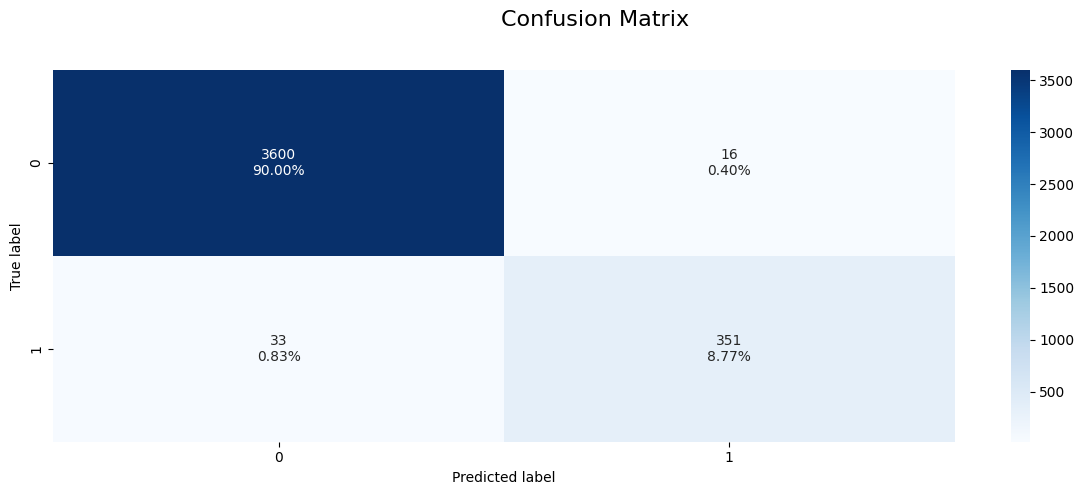

In [ ]:
plot_confusion_matrix(dtree2, X_train, y_train)

In [ ]:
dtree2_train_perf = evaluate_model(
    dtree2, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.98775,0.914062,0.956403,0.934754


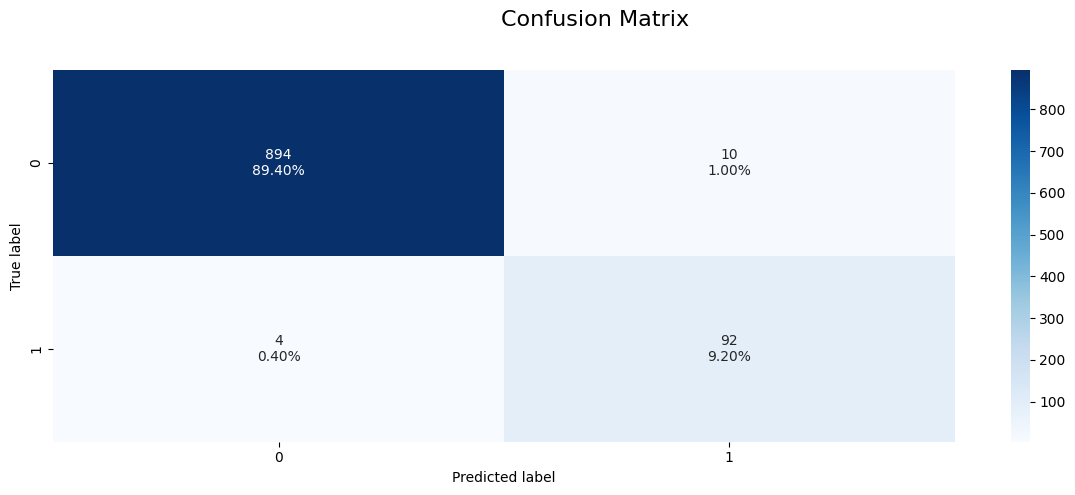

In [ ]:
plot_confusion_matrix(dtree2, X_test, y_test)

In [ ]:
dtree2_test_perf = evaluate_model(
    dtree2, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.986,0.958333,0.901961,0.929293


- The training and test scores are very close to each other, indicating a generalized performance.

#### Visualizing the Decision Tree

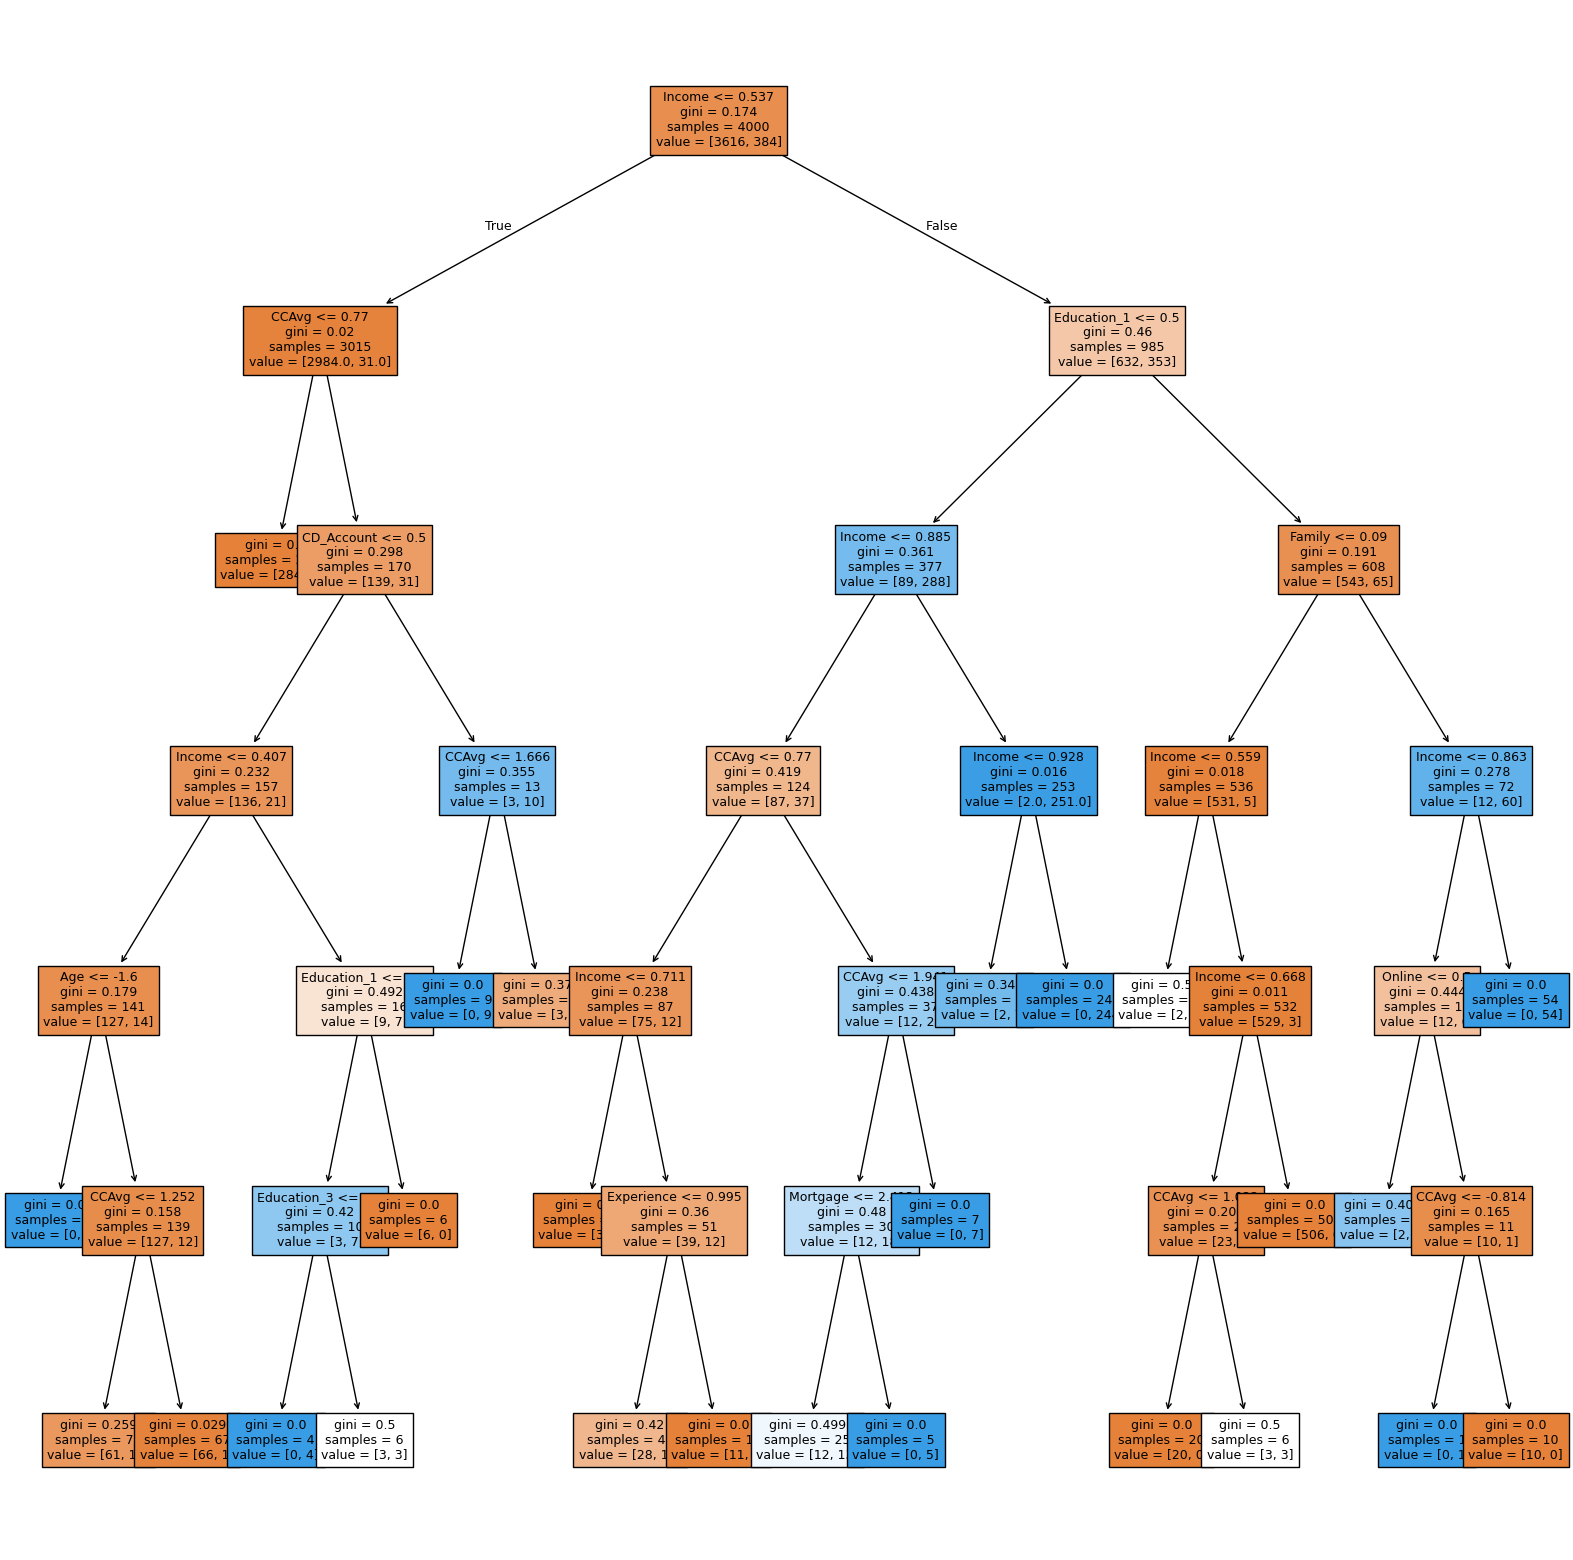

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- This is a far less complex tree than the previous one.
- We can observe the decision rules much more clearly in the plot.

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree2,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 0.54
|   |--- CCAvg <= 0.77
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  0.77
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 0.41
|   |   |   |   |--- Age <= -1.60
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  -1.60
|   |   |   |   |   |--- CCAvg <= 1.25
|   |   |   |   |   |   |--- weights: [61.00, 11.00] class: 0
|   |   |   |   |   |--- CCAvg >  1.25
|   |   |   |   |   |   |--- weights: [66.00, 1.00] class: 0
|   |   |   |--- Income >  0.41
|   |   |   |   |--- Education_1 <= 0.50
|   |   |   |   |   |--- Education_3 <= 0.50
|   |   |   |   |   |   |--- weights: [0.00, 4.00] class: 1
|   |   |   |   |   |--- Education_3 >  0.50
|   |   |   |   |   |   |--- weights: [3.00, 3.00] class: 0
|   |   |   |   |--- Education_1 >  0.50
|   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- CCAvg <= 1.67
|   |   |   |   |--- weights: [0.00, 9.00] class: 1
|  

### Decision Tree (Post-pruning)

In [ ]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000244,0.000487
2,0.000246,0.000980
3,0.000296,0.001869
4,0.000306,0.002788
5,0.000331,0.003780
6,0.000333,0.004113
7,0.000333,0.004446
8,0.000333,0.004780
9,0.000350,0.005830


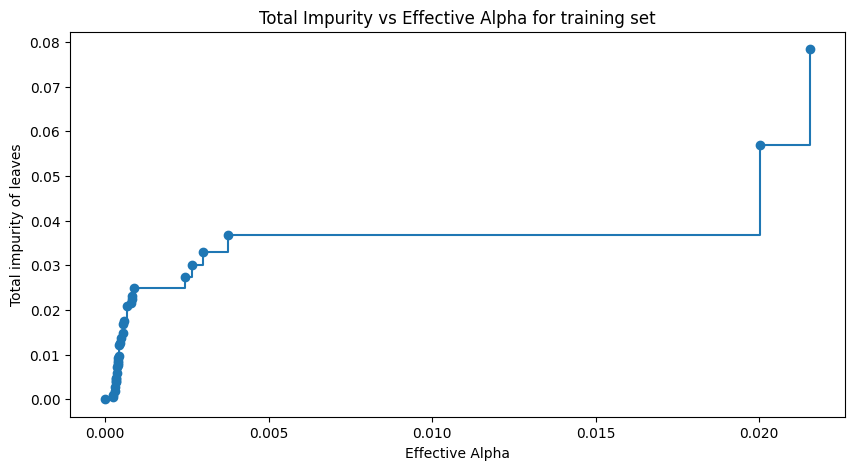

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

- Train a decision tree using the effective alphas.

- The last value in `ccp_alphas` is the alpha value that prunes the whole tree,
leaving the corresponding tree with one node.

In [ ]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
  # Create an instance of the DecisionTreeClassifier
  clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

  # Fit the classifier to the training data
  clf.fit(X_train, y_train)

  # Append the trained classifier to the list
  clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.04760359071815694


- Remove the last element in
``clfs`` and ``ccp_alphas`` as it corresponds to a trivial tree with only one
node.

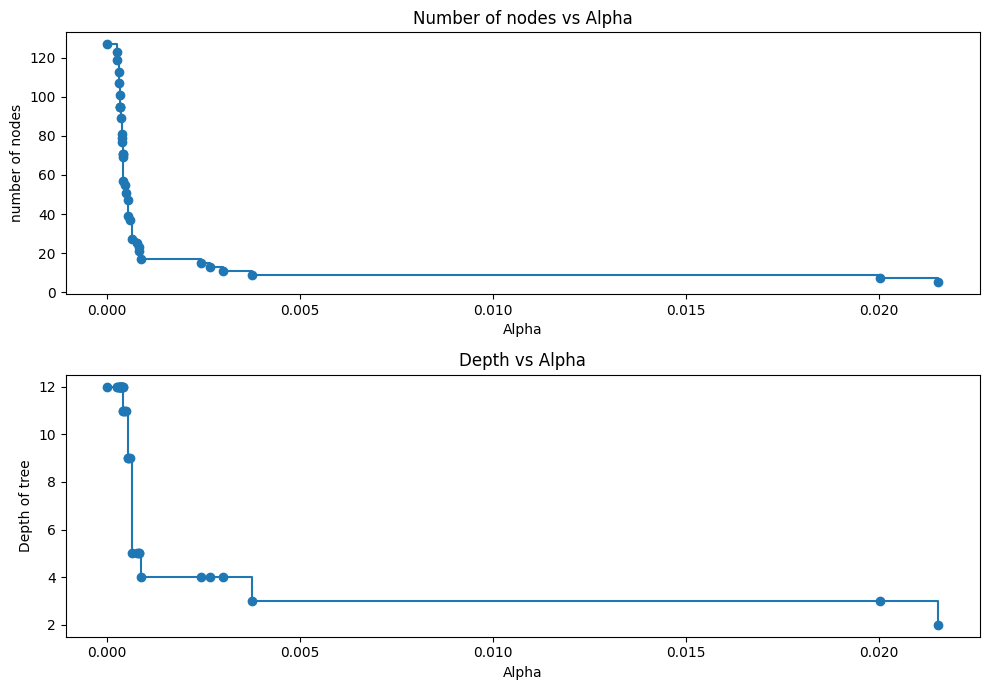

In [ ]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots clfs
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

In [ ]:
# Initialize an empty list to store F1 scores for training set for each decision tree classifier
train_f1_scores = []

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
  # Predict labels for the training set using the current decision tree classifier
  pred_train = clf.predict(X_train)

  # Calculate the F1 score for the training set predictions compared to true labels
  f1_train = f1_score(y_train, pred_train)

  # Append the calculated F1 score to the train_f1_scores list
  train_f1_scores.append(f1_train)

In [ ]:
# Initialize an empty list to store F1 scores for test set for each decision tree classifier
test_f1_scores = []

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
  # Predict labels for the test set using the current decision tree classifier
  pred_test = clf.predict(X_test)

  # Calculate the F1 score for the test set predictions compared to true labels
  f1_test = f1_score(y_test, pred_test)

  # Append the calculated F1 score to the test_f1_scores list
  test_f1_scores.append(f1_test)

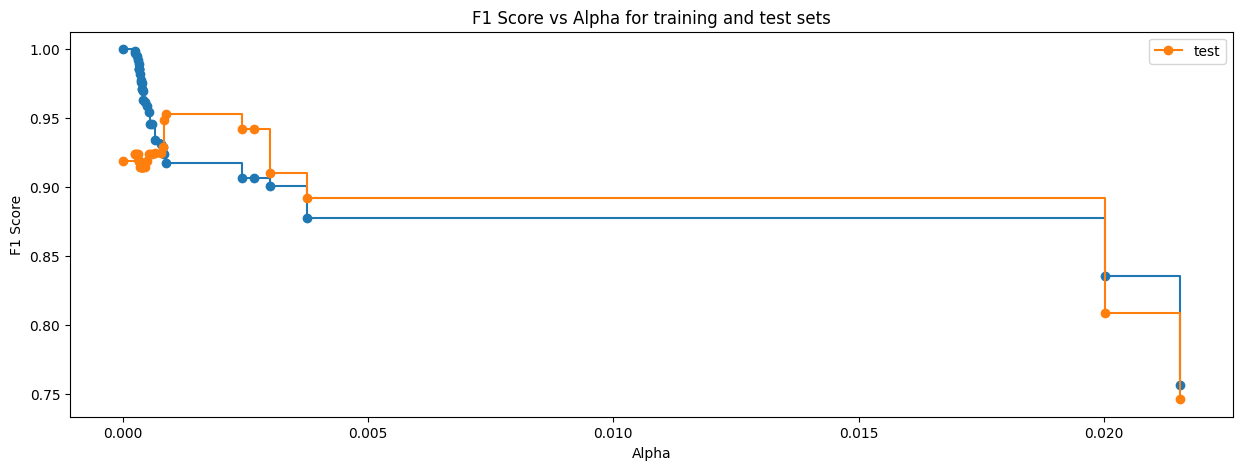

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")                # Set the label for the x-axis
ax.set_ylabel("F1 Score")             # Set the label for the y-axis
ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_f1_scores, marker="o", drawstyle="steps-post")

# Plot the testing F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_f1_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

In [ ]:
# creating the model where we get highest test F1 Score
index_best_model = np.argmax(test_f1_scores)

# selcting the decision tree model corresponding to the highest test score
dtree3 = clfs[index_best_model]
print(dtree3)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0008702884311333967),
                       random_state=42)


#### Model Evaluation

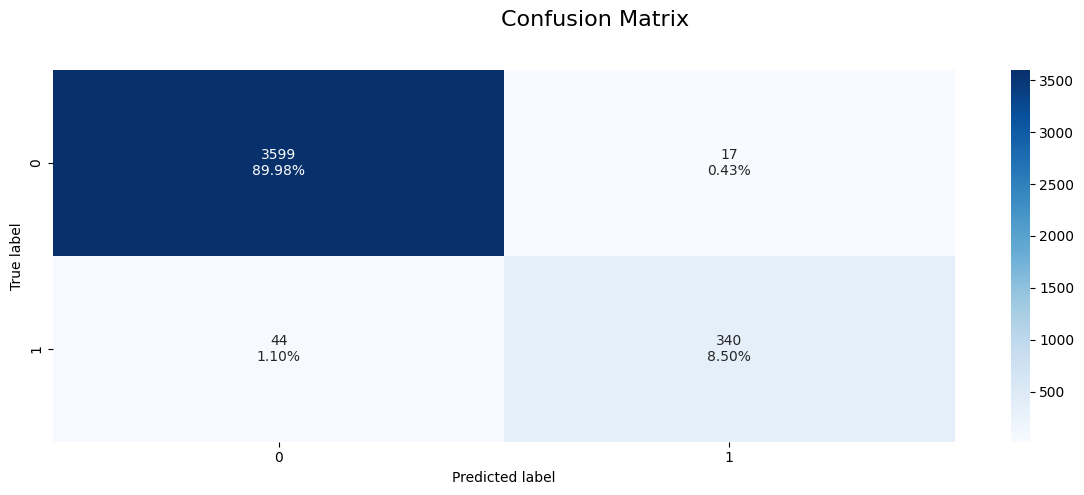

In [ ]:
plot_confusion_matrix(dtree3, X_train, y_train)

In [ ]:
dtree3_train_perf = evaluate_model(
    dtree3, X_train, y_train
)
dtree3_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.98475,0.885417,0.952381,0.917679


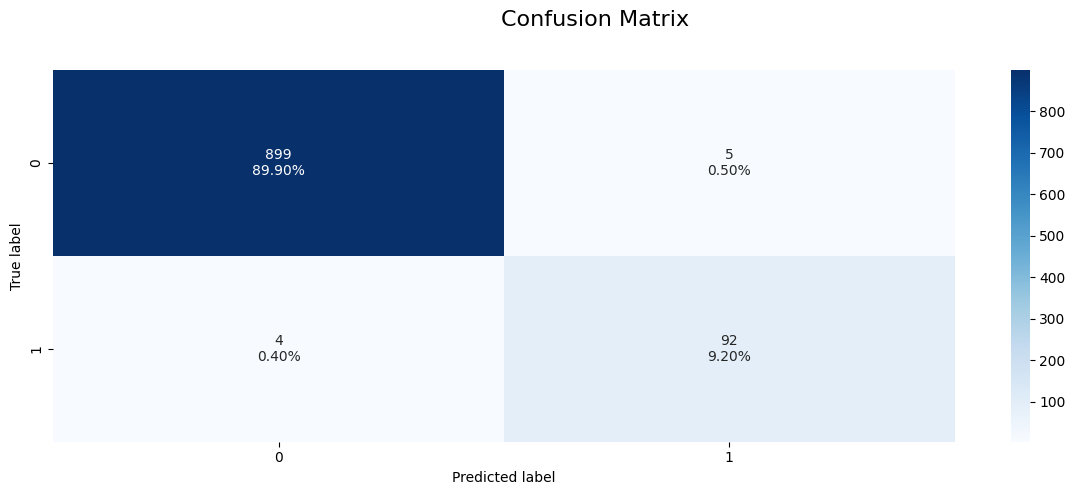

In [ ]:
plot_confusion_matrix(dtree3, X_test, y_test)

In [ ]:
dtree3_test_perf = evaluate_model(
    dtree3, X_test, y_test
)
dtree3_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.991,0.958333,0.948454,0.953368


- The test score is greater than the training score, indicating a generalized performance.

#### Visualizing Decision Tree

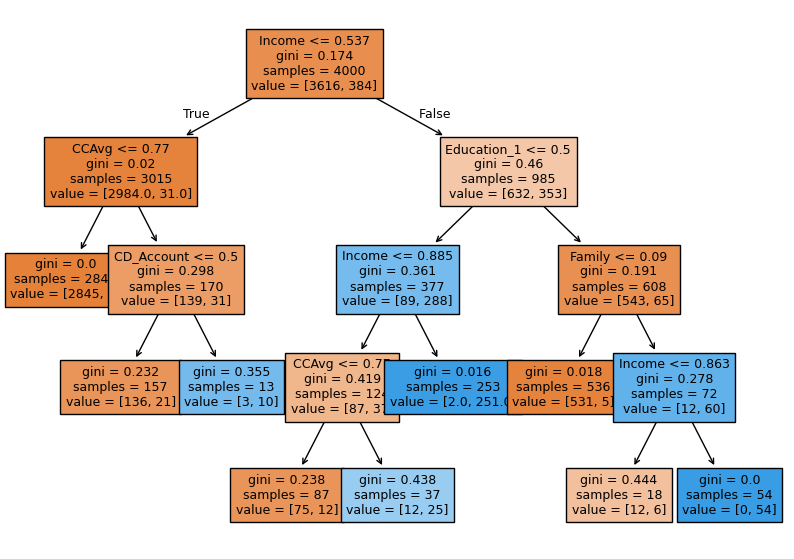

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(10, 7))

# plotting the decision tree
out = tree.plot_tree(
    dtree3,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- This is a far less complex tree than the previous one.
- Model used Income, CCAvg, Education, Family and CD_Account to determine probability of purchasing the loan.

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree3,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 0.54
|   |--- CCAvg <= 0.77
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  0.77
|   |   |--- CD_Account <= 0.50
|   |   |   |--- weights: [136.00, 21.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 10.00] class: 1
|--- Income >  0.54
|   |--- Education_1 <= 0.50
|   |   |--- Income <= 0.88
|   |   |   |--- CCAvg <= 0.77
|   |   |   |   |--- weights: [75.00, 12.00] class: 0
|   |   |   |--- CCAvg >  0.77
|   |   |   |   |--- weights: [12.00, 25.00] class: 1
|   |   |--- Income >  0.88
|   |   |   |--- weights: [2.00, 251.00] class: 1
|   |--- Education_1 >  0.50
|   |   |--- Family <= 0.09
|   |   |   |--- weights: [531.00, 5.00] class: 0
|   |   |--- Family >  0.09
|   |   |   |--- Income <= 0.86
|   |   |   |   |--- weights: [12.00, 6.00] class: 0
|   |   |   |--- Income >  0.86
|   |   |   |   |--- weights: [0.00, 54.00] class: 1



## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison
models_train_comp_df = pd.concat(
    [
        dtree1_train_perf.T,
        dtree2_train_perf.T,
        dtree3_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (pre-pruning)",
    "Decision Tree (post-pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (pre-pruning),Decision Tree (post-pruning)
Accuracy,1.0,0.987750,0.984750
Recall,1.0,0.914062,0.885417
Precision,1.0,0.956403,0.952381
F1 Score,1.0,0.934754,0.917679


In [ ]:
# testing performance comparison
models_test_comp_df = pd.concat(
    [
        dtree1_test_perf.T,
        dtree2_test_perf.T,
        dtree3_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.984000,0.986000,0.991000
Recall,0.947917,0.958333,0.958333
Precision,0.892157,0.901961,0.948454
F1 Score,0.919192,0.929293,0.953368


- Pre-pruned and post-pruned decision trees exhibit generalized performances.
- The post-pruned decision tree outperforms pre-pruned decision tree on the test set.
   - Accuracy: With a score of 0.991000, it has the highest accuracy.

   - Precision: With a score of 0.948454, it has the highest precision.

   - Recall & F1 Score: It is tied for the highest recall score of 0.958333 and has the highest F1 Score of 0.953368.

- Given that the Post-Pruning model demonstrates the best and most consistent performance across all key metrics on the testing dataset, it is the most robust and reliable choice.

## Actionable Insights and Business Recommendations


### Feature Importance

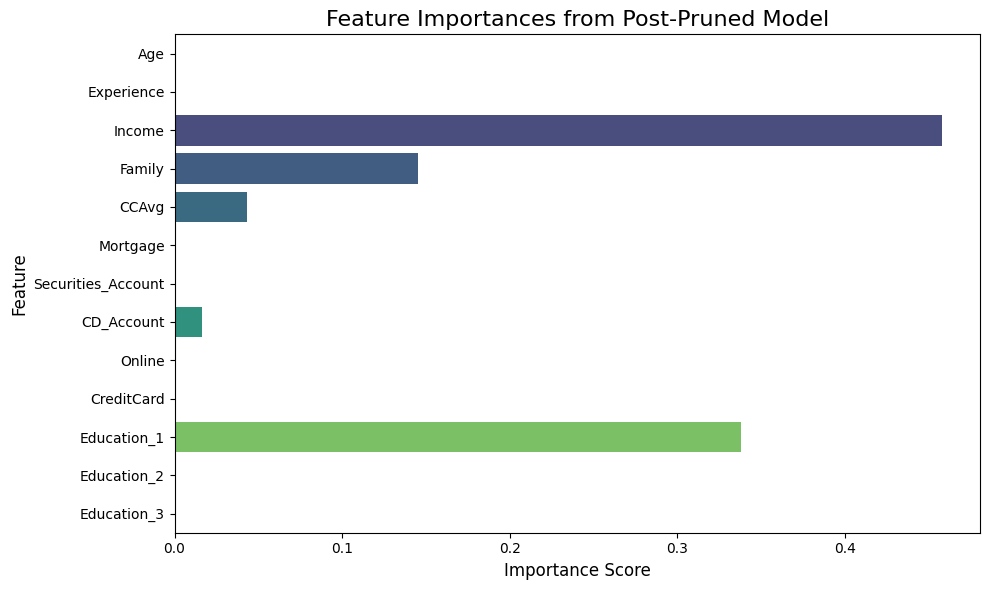

In [ ]:
# Plotting Feature Importance
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': dtree3.feature_importances_})

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances from Post-Pruned Model', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()


### Actionable Insights

- Using the post-pruned model, I have identified the most important features that influence a customer's decision to accept a personal loan. These insights can be used to formulate a more effective marketing and targeting strategy for the bank.
  - **Income**: This is, by far, the most significant predictor of a customer's interest in a loan.
  - **CCAvg**: The average monthly spending on a credit card is the second most important feature
  - **Education Level**: Customers with a graduate or professional education are much more likely to accept a loan.
  - **Family Size**: The number of family members is a key factor
  - **CD Account**: Customers with a Certificate of Deposit (CD) account are more likely to take a personal loan.

# **Business Recommendations**

- Based on these findings, here are my recommendations for the bank:
  - **Target High-Income Customers**: The most effective way to improve personal loan acquisition is to focus marketing efforts on customers in higher income brackets.
  - **Leverage Credit Card Spending Data**: Identify customers with high average credit card spending. These individuals represent a strong potential target group for personal loan offers.
  - **Focus on Graduate and Professional Customers**: Tailor your marketing campaigns to customers with advanced education. These customers have a significantly higher loan acceptance rate.
  - **Promote Personal Loans to Customers with CD Accounts**: The data shows a strong correlation between having a CD account and taking a personal loan. This suggests that customers who use the bank for long-term savings are also interested in long-term financial products like a loan.
  - **Create Targeted Bundles**: Develop and promote a "premier" or "full-service" banking package that bundles personal loans with other products like credit cards and CD accounts, as these products are frequently associated with loan-taking behavior.


___